In [ ]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [195]:
img = cv2.imread('./test_images/Drake0.jpg')
img.shape

(831, 770, 3)

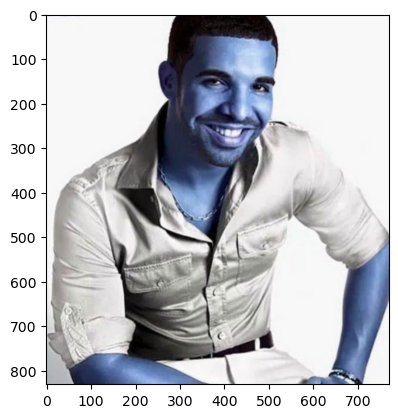

In [196]:
plt.imshow(img)
plt.show()


In [197]:
# convert to grayscale
gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gray.shape)

(831, 770)


In [198]:
gray

array([[244, 245, 247, ..., 248, 248, 248],
       [246, 247, 248, ..., 248, 248, 248],
       [249, 249, 249, ..., 248, 248, 248],
       ...,
       [180, 180, 180, ..., 248, 248, 248],
       [180, 180, 180, ..., 248, 248, 248],
       [180, 180, 180, ..., 248, 248, 248]], dtype=uint8)

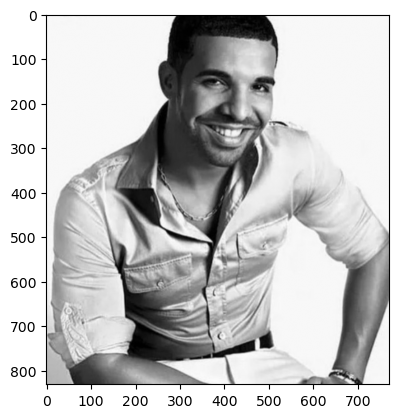

In [199]:
plt.imshow(gray, cmap='gray')
plt.show()

In [200]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[301,  55, 263, 263]], dtype=int32)

In [201]:
(x,y,w,h)=faces[0]
x,y,w,h

(np.int32(301), np.int32(55), np.int32(263), np.int32(263))

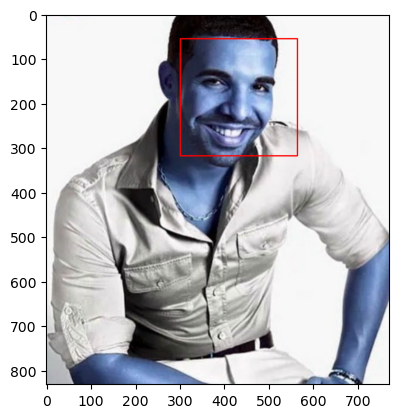

In [202]:
face_img=cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0), 2)
plt.imshow(face_img)
plt.show()


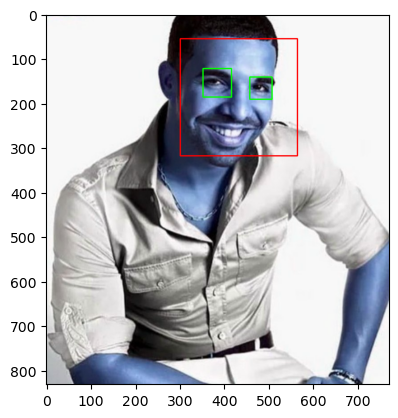

In [203]:
# using haarcascade to detect faces
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

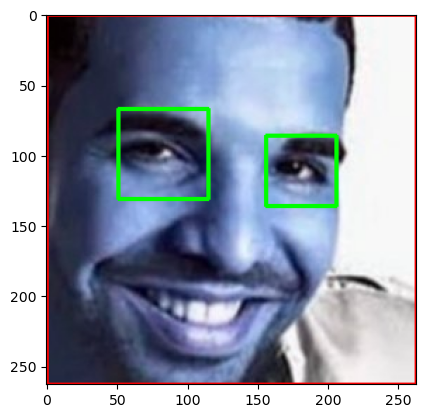

In [204]:
# cropping the face
%matplotlib inline
plt.imshow(roi_color, cmap='gray')
plt.show()

In [205]:
cropped_img = np.array(roi_color)
print(cropped_img.shape)

(263, 263, 3)


In [ ]:
# wavelet transform function
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

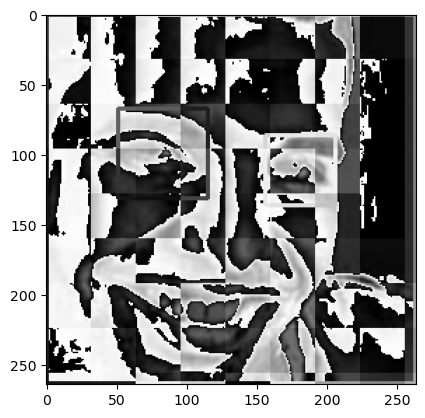

In [207]:
im_har = w2d(cropped_img,'db1',5)
plt.imshow(im_har, cmap='gray')
plt.show()

In [208]:
# take the input image and return the cropped image if 2 eyes are detected
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

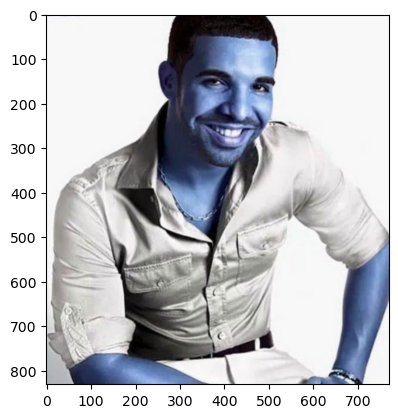

In [209]:
original_image = cv2.imread('./test_images/Drake0.jpg')
plt.imshow(original_image)
plt.show()

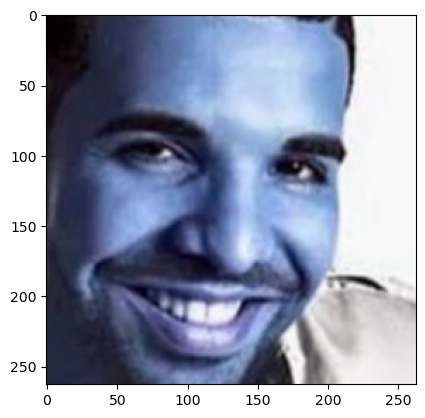

In [210]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/Drake0.jpg')
plt.imshow(cropped_image)
plt.show()

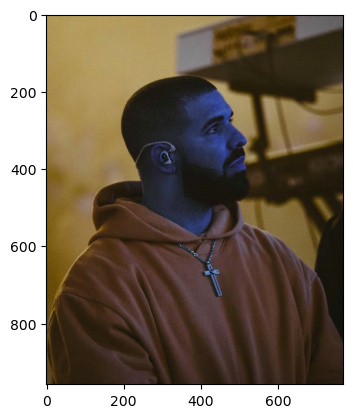

In [211]:
org_image_obstructed = cv2.imread('./test_images/Drake1.jpg')
plt.imshow(org_image_obstructed)
plt.show()

In [212]:
cropped_image_no_2_eyes = get_cropped_image_if_2_eyes('./test_images/Drake1.jpg')
cropped_image_no_2_eyes

# Above cropped_image_no_2_eyes is None which means we should ignore this image and we will not use such image for model training

path_to_data = "./dataset/"
path_to_cr_data = "./dataset/cropped/"

In [213]:
path_to_data = "./dataset/"
path_to_cr_data = "./dataset/cropped/"

In [214]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [215]:
img_dirs

['./dataset/Katy_perry',
 './dataset/Justin_Bieber',
 './dataset/Post_Malone',
 './dataset/Drake',
 './dataset/cropped',
 './dataset/Salena_Gomez']

In [216]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [217]:
cropped_image_dirs = []
celebrity_file_names_dict = {}
for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    celebrity_file_names_dict[celebrity_name] = []
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

Generating cropped images in folder:  ./dataset/cropped/Katy_perry
Generating cropped images in folder:  ./dataset/cropped/Justin_Bieber
Generating cropped images in folder:  ./dataset/cropped/Post_Malone
Generating cropped images in folder:  ./dataset/cropped/Drake
Generating cropped images in folder:  ./dataset/cropped/Salena_Gomez


libpng warning: iCCP: known incorrect sRGB profile


In [234]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
celebrity_file_names_dict

{'Katy_perry': ['./dataset/cropped/Katy_perry/Katy_perry68.png',
  './dataset/cropped/Katy_perry/Katy_perry40.png',
  './dataset/cropped/Katy_perry/Katy_perry54.png',
  './dataset/cropped/Katy_perry/Katy_perry55.png',
  './dataset/cropped/Katy_perry/Katy_perry69.png',
  './dataset/cropped/Katy_perry/Katy_perry57.png',
  './dataset/cropped/Katy_perry/Katy_perry43.png',
  './dataset/cropped/Katy_perry/Katy_perry42.png',
  './dataset/cropped/Katy_perry/Katy_perry56.png',
  './dataset/cropped/Katy_perry/Katy_perry52.png',
  './dataset/cropped/Katy_perry/Katy_perry46.png',
  './dataset/cropped/Katy_perry/.DS_Store',
  './dataset/cropped/Katy_perry/Katy_perry47.png',
  './dataset/cropped/Katy_perry/Katy_perry53.png',
  './dataset/cropped/Katy_perry/Katy_perry45.png',
  './dataset/cropped/Katy_perry/Katy_perry51.png',
  './dataset/cropped/Katy_perry/Katy_perry50.png',
  './dataset/cropped/Katy_perry/Katy_perry44.png',
  './dataset/cropped/Katy_perry/Katy_perry23.png',
  './dataset/cropped/Kat

In [235]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'Katy_perry': 0,
 'Justin_Bieber': 1,
 'Post_Malone': 2,
 'Drake': 3,
 'Salena_Gomez': 4}

In [236]:
X, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            print("Skipping unreadable image:", training_image)
            continue
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name]) 

Skipping unreadable image: ./dataset/cropped/Katy_perry/.DS_Store
Skipping unreadable image: ./dataset/cropped/Justin_Bieber/.DS_Store
Skipping unreadable image: ./dataset/cropped/Drake/.DS_Store
Skipping unreadable image: ./dataset/cropped/Salena_Gomez/.DS_Store


In [237]:
len(X[0])

4096

In [238]:
X[0]

array([[236],
       [246],
       [246],
       ...,
       [238],
       [ 19],
       [251]], dtype=uint8)

In [239]:
y[0]

0

In [240]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(263, 4096)

In [241]:
# Training the model
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [242]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.7424242424242424

In [243]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.75      0.80      0.77        15
           1       0.62      0.91      0.74        11
           2       1.00      0.33      0.50        15
           3       0.74      0.93      0.82        15
           4       0.80      0.80      0.80        10

    accuracy                           0.74        66
   macro avg       0.78      0.76      0.73        66
weighted avg       0.79      0.74      0.72        66



In [244]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [245]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [259]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.691154,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.482949,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.731282,{'logisticregression__C': 1}


In [260]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, multi_class='auto',
                                     solver='liblinear'))])}

In [261]:
best_estimators['svm'].score(X_test,y_test)

0.803030303030303

In [262]:
best_estimators['random_forest'].score(X_test,y_test)

0.6212121212121212

In [263]:
best_estimators['logistic_regression'].score(X_test,y_test)

0.8181818181818182

In [264]:
best_clf = best_estimators['svm']

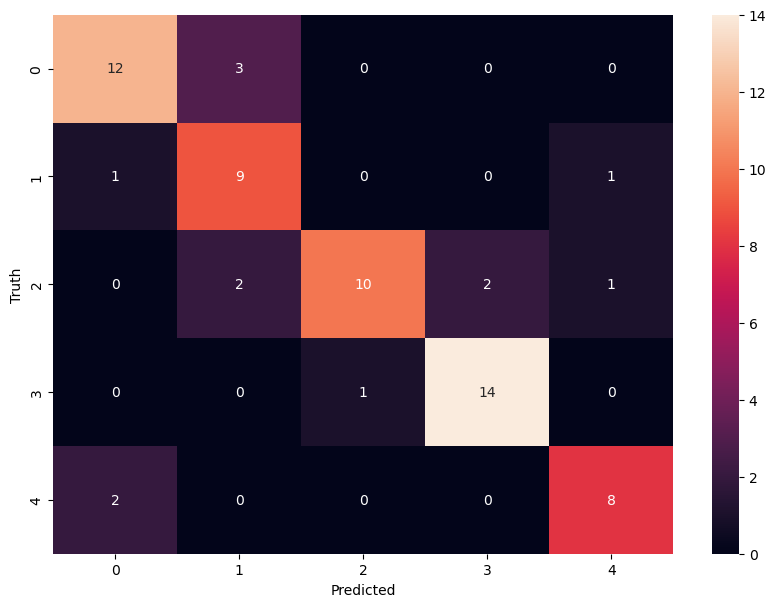

In [ ]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [266]:
class_dict


{'Katy_perry': 0,
 'Justin_Bieber': 1,
 'Post_Malone': 2,
 'Drake': 3,
 'Salena_Gomez': 4}

In [257]:
!pip install joblib
import joblib 
# Saved the model as a pickle in a file 
joblib.dump(best_clf, 'saved_model.pkl') 

['saved_model.pkl']

In [258]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))